#数理統計学 学習ノート


2023年前期 須藤龍一

これは授業資料から大幅に引用しながら自分のために作った学習ノートを、公開用にある程度整理(課題の答案や、自身の作業成果ではない元資料からの引用など削除)したものです。
定義した各クラスを実際に使用しているコードの前後だけを残しています。


もととなっている資料は 東北大学大学院理学研究科の黒木玄助教 のリポジトリ https://github.com/genkuroki/Statistics/tree/master で、このリポジトリの中で説明されている内容や、Julia言語で実装されている統計手法を Python で実装しています。

授業課題を解くために必要な範囲をカバーすることが目的であり、元リポジトリのすべての内容を網羅しているわけではないことにご留意ください。

ファイルの構成

- コードまとめ : 授業で扱った統計分布の定義(各分布には期待値、分散などの基本的なパラメータを得るプロパティと、確率密度(質量)関数、累積分布関数などの確率関数、実際にデータ系列を確率分布に従って生成する関数などが含まれます)

- 前編：統計分布の紹介と自作クラスの使用例

- 後編：いくつかの検定手法の実行例

## コードまとめ

In [20]:
import random as rd
import numpy as np
import matplotlib.pyplot as plt
import math
import statistics as stcs
import scipy as sp

### tools

In [21]:
# 二項係数など

def My_GetExpectationDPD(pDict):
  "辞書で与えられた確率質量函数から期待値を返す"
  result = 0.
  for k, v in pDict.items():
    result += k * v
  return result

def My_GetVarianceDPD(pDict):
  "辞書で与えられた確率質量函数から分散を返す"
  result = 0.
  mean = My_GetExpectationDPD(pDict)
  for k, v in pDict.items():
    result += ((k - mean)**2) * v
  return result

def My_GetStandardDeviationDPD(pDict):
  "辞書で与えられた確率質量函数から標準偏差を返す"
  return math.sqrt(My_GetVarianceDPD(pDict))

def My_GetMedianDPD(pDict):
  "辞書型で与えられた確率質量函数から中央値を返す"
  result = 0
  total = 0.
  keyList = sorted(pDict)
  for k in keyList:
    total += pDict[k]
    if total >= 0.5:
      result = k
      break
  return result

def My_P2Odds(p):
  "確率からオッズを返す"
  return p/(1-p)

def My_Odds2P(o):
  "オッズから確率を返す"
  return o/(1+o)

def My_GetLogit(p):
  "ロジット変換を返す"
  return math.log(My_P2Odds(p))

def My_GetLogistic(x):
  "ロジスティック変換を返す"
  return 1/(1+math.exp(x))

def My_GetCombination(n, k):
  "二項係数を返す"
  result = 1
  for i in range(n, n-k, -1):
    result *= i
  for i in range(1, k+1):
    result //= i
  return result

def My_Stirling(n):
  "階乗を近似式で計算する"
  result = (n**n) * math.exp(-n) * math.sqrt(2 * math.pi * n)
  return result


### 1 Bernoulli

In [22]:
class My_BernoulliDist():
  """自作のベルヌイ試行"""
  def __init__(self, p=0.5, *, seed = None):
    self.p = p
    self.rgm = rd.Random()
    self.seed = seed
    pass

  @property
  def seed(self):
    "seedのgetter"
    return self.__seed

  @seed.setter
  def seed(self, value):
    "seedのsetter"
    self.__seed = value
    self.reset()
    return

  @property
  def p(self):
    "確率pのgetter"
    return self.__p

  @p.setter
  def p(self, p):
    "確率pのsetter"
    self.__p = p
    self.__mean = p
    self.__median = self.inv_cdf(0.5)

    if self.__p < 0.5:
      self.__mode = 0
    elif self.__p == 0.5:
      self.__mode = [0, 1]
    else:
      self.__mode = 1

    self.__variance = p * (1-p)

    self.__stdev = math.sqrt(self.__variance)
    return

  @property
  def mean(self):
    "期待値meanのgetter"
    return self.__mean

  @property
  def median(self):
    "中央値medianのgetter"
    return self.__median

  @property
  def mode(self):
    "最頻値modeのgetter"
    return self.__mode

  @property
  def stdev(self):
    "標準偏差stdevのgetter"
    return self.__stdev

  @property
  def variance(self):
    "分散varianceのgetter"
    return self.__variance

  @classmethod
  def from_samples (cls, data):
    "サンプルデータから分布を作成、データの平均値をpとする"
    return cls(stcs.fmean(data))

  def reset(self):
    "乱数生成器のリセット"
    self.rgm.seed(self.__seed)
    return self

  def samples(self, n):
    "n回試行を行う"
    result = []
    for i in range(n):
      result.append(self.inv_cdf(self.rgm.random()))
    return result

  def pmf(self, x):
    "確率質量函数"
    result = 0.0
    if x == 0:
      result = 1-self.__p
    elif x == 1:
      result = self.__p
    return result

  def cdf(self, x):
    "累積分布関数"
    result = 0.0
    if x < 0:
      result = 0
    elif (0 <= x) and (x < 1):
      result = 1-self.__p
    else:
      result = 1.0
    return result

  def inv_cdf(self, p):
    "分位点函数"
    result = None
    if (p <= 0) or (1 < p):
      result = None
    elif p <= (1-self.__p):
      result = 0
    elif (1-self.__p)<p:
      result = 1
    return result

  def quantiles(self, n=4):
    "分位点を求める"
    result = []
    for i in range(1, n):
      result.append(self.inv_cdf(i/n))
    return result

  def zscore(self, x):
    "偏差値zスコア"
    return (x-self.__mean)/self.__stdev

### 2 Categorical

In [23]:
class My_CategoricalDist():
  """自作のカテゴリカル分布"""
  def __init__(self, pList, *, seed=None):
    self.pDist = pList
    self.rgm = rd.Random()
    self.seed = seed
    return

  @property
  def seed(self):
    "seedのgetter"
    return self.__seed

  @seed.setter
  def seed(self, value):
    "seedのsetter"
    self.__seed = value
    self.reset()
    return

  @property
  def pDist(self):
    "辞書型の確率分布pDistのgetter"
    return self.__pDist

  @pDist.setter
  def pDist(self, value):
    "確率分布pDistのsetter"
    pDict = {}
    for i in range(len(value)):
      pDict[i+1] = value[i]
    self.__pDist = pDict

    self.__mean = 0.
    for i, v in self.__pDist.items():
      self.__mean += (i * v)

    self.__median = self.inv_cdf(0.5)

    self.__mode =[]
    maxP = 0
    for i, v in self.__pDist.items():
      if v == maxP:
        if type(self.__mode) == list:
          self.__mode.append(i)
        else:
          self.__mode = [self.__mode, i]
      elif v > maxP:
        self.__mode = i
        maxP = v

    self.__variance = 0.
    for i, v in self.__pDist.items():
      self.__variance += ((i - self.__mean)**2) * v

    self.__stdev = math.sqrt(self.__variance)
    return

  @property
  def mean(self):
    "期待値meanのgetter"
    return self.__mean

  @property
  def median(self):
    "中央値medianのgetter"
    return self.__median

  @property
  def mode(self):
    "最頻値modeのgetter"
    return self.__mode

  @property
  def stdev(self):
    "標準偏差stdevのgetter"
    return self.__stdev

  @property
  def variance(self):
    "分散varianceのgetter"
    return self.__variance

  @classmethod
  def from_samples (cls, data):
    "サンプルデータから分布を作成、自然数のリストを引数とする"
    pList = []
    for i in data:
      if (not (type(i) == int)) or (i <= 0):
        pList = [0.1, 0.2, 0.3, 0.4]
        return cls(pList)

    for i in range(1, int(max(data)+1)):
      iCount=0
      for j in data:
        if j == i:
          iCount += 1
      pList.append(iCount/len(data))
    return cls(pList)

  def reset(self):
    "乱数生成器のリセット"
    self.rgm.seed(self.__seed)
    return self

  def samples(self, n):
    "n回試行を行う"
    result = []
    for i in range(n):
      result.append(self.inv_cdf(self.rgm.random()))
    return result

  def pmf(self, x):
    "確率質量函数"
    result = 0
    if x in self.__pDist.keys():
      result = self.__pDist[x]
    else:
      result = 0
    return result

  def cdf(self, x):
    "累積分布関数"
    result = 0.
    if x < 1:
      result = 0.
    elif x >= len(self.__pDist):
      result = 1.0
    else:
      for i in range(1, int(x)+1):
        result += self.__pDist[i]
    return result

  def inv_cdf(self, p):
    "分位点函数"
    result = None
    if (0 < p) or (p < 1):
      for i in range(1,len(self.__pDist)+1):
        if (self.cdf(i-1) < p) and (p <= self.cdf(i)):
          result = i
          break
    return result

  def quantiles(self, n=4):
    "分位点を求める"
    result = []
    for i in range(1, n):
      result.append(self.inv_cdf(i/n))
    return result

  def zscore(self, x):
    "偏差値zスコア"
    return (x-self.__mean)/self.__stdev

### 3 二項分布

In [24]:

class My_BinomialDist():
  "自作の二項分布"
  def __init__(self, n, p, *, seed=None):
    "コンストラクタ"
    self.__n = n
    self.p = p
    self.rgm = rd.Random()
    self.seed = seed
    return

  @property
  def seed(self):
    "seedのgetter"
    return self.__seed

  @seed.setter
  def seed(self, value):
    "seedのsetter"
    self.__seed = value
    self.reset()
    return

  @property
  def n(self):
    "試行回数nのgetter"
    return self.__n

  @n.setter
  def n(self, value):
    "試行回数nのsetter"
    self.__n = value
    self.p = self.__p
    return

  @property
  def p(self):
    "成功確率pのgetter"
    return self.__p

  @p.setter
  def p(self, value):
    "成功確率pのsetter"
    self.__p = value
    self.__mean = self.__n * self.__p
    self.__median = self.inv_cdf(0.5)

    self.__mode =[]
    maxP = 0
    for i in range(self.__n+1):
      if self.pmf(i) == maxP:
        if type(self.__mode) == list:
          self.__mode.append(i)
        else:
          self.__mode = [self.__mode, i]
      elif self.pmf(i) > maxP:
        self.__mode = i
        maxP = self.pmf(i)

    self.__variance = self.__n * self.__p * (1 - self.__p)

    self.__stdev = math.sqrt(self.__variance)

    return

  @property
  def mean(self):
    "期待値meanのgetter"
    return self.__mean

  @property
  def median(self):
    "中央値medianのgetter"
    return self.__median

  @property
  def mode(self):
    "最頻値modeのgetter"
    return self.__mode

  @property
  def stdev(self):
    "標準偏差stdevのgetter"
    return self.__stdev

  @property
  def variance(self):
    "分散varianceのgetter"
    return self.__variance

  @classmethod
  def from_samples (cls, data):
    "サンプルデータから分布を作成、平均値np,分散np(1-p)となるn,pを算出"
    m = stcs.fmean(data)
    v = stcs.variance(data)
    p = 1 - v/m
    n = m/p
    return cls(n, p)

  def reset(self):
    "乱数生成器のリセット"
    self.rgm.seed(self.__seed)
    return self

  def samples(self, n):
    "n回試行を行う"
    result = []
    for i in range(n):
      result.append(self.inv_cdf(self.rgm.random()))
    return result

  def pmf(self, x):
    "確率質量函数"
    result = 0;
    if (int(x) in range(0, self.__n+1)) and math.isclose(x, int(x)):
      x = int(x)
      conbination = My_GetCombination(self.__n,x)
      result = conbination * (self.__p**x) * ((1-self.__p)**(self.__n-x))
    return result

  def cdf(self, x):
    "累積分布関数"
    result = 0
    if x >= 0:
      for i in range(int(x)+1):
        result += self.pmf(i)
    return result

  def inv_cdf(self, p):
    "分位点函数"
    result = None
    if (0 < p) or (p <= 1):
      for i in range(self.__n+1):
        if (self.cdf(i-1) < p)and(p <= self.cdf(i)):
          result = i
          break
    return result

  def quantiles(self, n=4):
    "分位点を求める"
    result = []
    for i in range(1, n):
      result.append(self.inv_cdf(i/n))
    return result

  def zscore(self, x):
    "偏差値zスコア"
    return (x-self.__mean)/self.__stdev

### 4 幾何分布

In [25]:
class My_GeometricDist():
  "自作の幾何分布"
  def __init__(self, p, *, seed=None):
    "コンストラクタ"
    self.p = p
    self.rgm = rd.Random()
    self.seed = seed
    return

  @property
  def seed(self):
    "seedのgetter"
    return self.__seed

  @seed.setter
  def seed(self, value):
    "seedのsetter"
    self.__seed = value
    self.reset()
    return

  @property
  def p(self):
    "成功確率pのgetter"
    return self.__p

  @p.setter
  def p(self, value):
    "成功確率pのsetter"
    self.__p = value
    self.__mean = (1 - self.__p) / self.__p
    self.__median = self.inv_cdf(0.5)

    self.__mode = 0

    self.__variance = (1 - self.__p) / (self.__p ** 2)

    self.__stdev = math.sqrt(self.__variance)

    return

  @property
  def mean(self):
    "期待値meanのgetter"
    return self.__mean

  @property
  def median(self):
    "中央値medianのgetter"
    return self.__median

  @property
  def mode(self):
    "最頻値modeのgetter"
    return self.__mode

  @property
  def stdev(self):
    "標準偏差stdevのgetter"
    return self.__stdev

  @property
  def variance(self):
    "分散varianceのgetter"
    return self.__variance

  @classmethod
  def from_samples (cls, data):
    "サンプルデータから分布を作成、期待値が(1-p)/pとなるpを算出"
    return cls(1/(stcs.fmean(data)+1))

  def reset(self):
    "乱数生成器のリセット"
    self.rgm.seed(self.__seed)
    return self

  def samples(self, n):
    "n回試行を行う"
    result = []
    for i in range(n):
      result.append(self.inv_cdf(self.rgm.random()))
    return result

  def pmf(self, x):
    "確率質量函数"
    result = 0;
    if (0 <= x) and math.isclose(x, int(x)):
      result = self.__p * ((1-self.__p)**x)
    return result

  def cdf(self, x):
    "累積分布関数"
    if 0 <= x:
      result = 1-((1-self.__p)**(int(x)+1))
    return result

  def inv_cdf(self, p):
    "分位点函数"
    result = None
    if (0 < p) or (p < 1):
      i = 0
      while True:
        if (p <= self.cdf(i)):
          result = i
          break
        i += 1
    return result

  def quantiles(self, n=4):
    "分位点を求める"
    result = []
    for i in range(1, n):
      result.append(self.inv_cdf(i/n))
    return result

  def zscore(self, x):
    "偏差値zスコア"
    return (x-self.__mean)/self.__stdev

### 5 負の二項分布

In [26]:
class My_NegativeBinomialDist():
  "自作の負の二項分布"
  def __init__(self, k, p, *, seed=None):
    "コンストラクタ"
    self.__k = k
    self.p = p
    self.rgm = rd.Random()
    self.seed = seed
    return

  @property
  def seed(self):
    "seedのgetter"
    return self.__seed

  @seed.setter
  def seed(self, value):
    "seedのsetter"
    self.__seed = value
    self.reset()
    return

  @property
  def k(self):
    "あたりの回数kのgetter"
    return self.__k

  @k.setter
  def k(self, value):
    "あたりの回数kのsetter"
    self.__k = value
    self.p = self.__p
    return

  @property
  def p(self):
    "成功確率pのgetter"
    return self.__p

  @p.setter
  def p(self, value):
    "成功確率pのsetter"
    self.__p = value

    self.__mean = self.__k * (1-self.__p)/self.__p
    self.__median = self.inv_cdf(0.5)

    self.__mode = 0
    if (self.__k-1)/self.__p == float(int((self.__k-1)/self.__p)):
      self.__mode = [int((self.__k-1)/self.__p)-1, int((self.__k-1)/self.__p)]
    else:
      self.__mode = int((self.__k-1)/self.__p)

    self.__variance = self.__k * (1-self.__p) / (self.__p**2)

    self.__stdev = math.sqrt(self.__variance)

    return

  @property
  def mean(self):
    "期待値meanのgetter"
    return self.__mean

  @property
  def median(self):
    "中央値medianのgetter"
    return self.__median

  @property
  def mode(self):
    "最頻値modeのgetter"
    return self.__mode

  @property
  def stdev(self):
    "標準偏差stdevのgetter"
    return self.__stdev

  @property
  def variance(self):
    "分散varianceのgetter"
    return self.__variance

  @classmethod
  def from_samples (cls, data):
    """サンプルデータから分布を作成、
    期待値がk(1-p)/p、分散がk(1-p)/(p^2)となるk,pを算出"""
    m = stcs.fmean(data)
    v = stcs.variance(data)
    p = m/v
    k = m*p/(1-p)
    return cls(k, p)

  def reset(self):
    "乱数生成器のリセット"
    self.rgm.seed(self.__seed)
    return self

  def samples(self, n):
    "n回試行を行う"
    result = []
    for i in range(n):
      result.append(self.inv_cdf(self.rgm.random()))
    return result

  def pmf(self, x):
    "確率質量函数"
    result = 0
    if (0 <= x) and math.isclose(x, int(x)):
      x=int(x)
      result = My_GetCombination(self.__k+x-1, x)*(self.__p**self.__k)*((1-self.__p)**x)
    return result

  def cdf(self, x):
    "累積分布関数"
    result = 0
    if x >= 0:
      for i in range(int(x)+1):
        result += self.pmf(i)
    return result

  def inv_cdf(self, p):
    "分位点函数"
    result = None
    if (0 < p) and (p < 1):
      i = 0
      while True:
        if (p <= self.cdf(i)):
          result = i
          break
        i += 1
    return result

  def quantiles(self, n=4):
    "分位点を求める"
    result = []
    for i in range(1, n):
      result.append(self.inv_cdf(i/n))
    return result

  def zscore(self, x):
    "偏差値zスコア"
    return (x-self.__mean)/self.__stdev

### 6 一様分布

In [27]:
class My_UniformDist():
  """自作の一様分布クラス"""
  def __init__(self, a=0, b=1, *, seed=None):
    "コンストラクタ"
    self.__a = a
    self.b = b
    self.rgm = rd.Random()
    self.seed = seed
    return

  @property
  def seed(self):
    "seedのgetter"
    return self.__seed

  @seed.setter
  def seed(self, value):
    "seedのsetter"
    self.__seed = value
    self.reset()
    return

  @property
  def a(self):
    "区間始点aのgetter"
    return self.__a

  @a.setter
  def a(self, value):
    "区間始点aのsetter"
    self.__a = value
    self.b = self.__b
    return

  @property
  def b(self):
    "区間終点bのgetter"
    return self.__b

  @b.setter
  def b(self, value):
    "区間終点bのsetter"
    self.__b = value

    self.__mean = (self.__a + self.__b) /2
    self.__median = self.__mean
    self.__mode = (self.__a, self.__b)
    self.__variance = ((self.__b - self.__a)**2) / 12
    self.__stdev = math.sqrt(self.__variance)

    return

  @property
  def mean(self):
    "期待値meanのgetter"
    return self.__mean

  @property
  def median(self):
    "中央値medianのgetter"
    return self.__median

  @property
  def mode(self):
    "最頻値modeのgetter"
    return self.__mode

  @property
  def stdev(self):
    "標準偏差stdevのgetter"
    return self.__stdev

  @property
  def variance(self):
    "分散varianceのgetter"
    return self.__variance

  @classmethod
  def from_samples (cls, data):
    """サンプルデータから分布を作成、
    平均値(a+b)/2, 分散(b-a)^2/12となるa,bを算出"""
    m = stcs.fmean(data)
    v = stcs.variance(data)
    m = 2*m
    v = math.sqrt(12*v)
    a = (m-v)/2
    b = (m+v)/2
    return cls(a,b)

  def reset(self):
    "乱数生成器のリセット"
    self.rgm.seed(self.__seed)
    return self

  def samples(self, n):
    "n回試行を行う"
    result = []
    for i in range(n):
      result.append(self.inv_cdf(self.rgm.random()))
    return result

  def pdf(self, x):
    "確率密度函数"
    result = 0
    if (self.__a < x) and (x < self.__b):
      result = 1/(self.__b - self.__a)
    return result

  def cdf(self, x):
    "累積分布関数"
    result = 0.
    if x <= self.__a:
      result = 0.
    elif (self.__a < x) and (x < self.__b):
      result = (x - self.__a) / (self.__b - self.__a)
    else:
      result = 1.0
    return result

  def inv_cdf(self, p):
    "分位点函数"
    result = None
    if (0 < p) or (p < 1):
      result = (self.__b - self.__a) * p + self.__a
    return result

  def quantiles(self, n=4):
    "分位点を求める"
    result = []
    for i in range(1, n):
      result.append(self.inv_cdf(i/n))
    return result

  def zscore(self, x):
    "偏差値zスコア"
    return (x-self.__mean)/self.__stdev

### 7 正規分布

In [28]:
class My_NormalDist():
  """自作の正規分布"""
  def __init__(self, m=0, s=1, *, seed=None):
    "コンストラクタ"
    self.__stdev = s
    self.mean = m
    self.rgm = rd.Random()
    self.seed = seed
    return

  @property
  def seed(self):
    "seedのgetter"
    return self.__seed

  @seed.setter
  def seed(self, value):
    "seedのsetter"
    self.__seed = value
    self.reset()
    return

  @property
  def mean(self):
    "期待値meanのgetter"
    return self.__mean

  @mean.setter
  def mean(self, value):
    "期待値meanのsetter"
    self.__mean = value

    self.__median = self.__mean
    self.__mode = self.__mean
    self.__variance = self.__stdev**2
    return

  @property
  def median(self):
    "中央値medianのgetter"
    return self.__median

  @property
  def mode(self):
    "最頻値modeのgetter"
    return self.__mode

  @property
  def stdev(self):
    "標準偏差stdevのgetter"
    return self.__stdev

  @stdev.setter
  def stdev(self, value):
    "標準偏差stdevのsetter"
    self.__stdev = value
    self.mean = self.__mean
    return

  @property
  def variance(self):
    "分散varianceのgetter"
    return self.__variance

  @classmethod
  def from_samples (cls, data):
    "サンプルデータから分布を作成,期待値m、不遍標準偏差sを算出"
    return cls(stcs.fmean(data), stcs.stdev(data))

  def reset(self):
    "乱数生成器のリセット"
    self.rgm.seed(self.__seed)
    return self

  def samples(self, n):
    "n回試行を行う"
    result = []
    for i in range(n):
      result.append(self.inv_cdf(self.rgm.random()))
    return result

  def pdf(self, x):
    "確率密度函数"
    result = math.exp(-(x-self.__mean)**2 / (2*self.__variance)) / (math.sqrt(2*math.pi) * self.__stdev)
    return result

  def cdf(self, x):
    "累積分布関数"
    result = (1 + math.erf( (x-self.__mean) / (math.sqrt(2)*self.__stdev))) / 2
    return result

  def inv_cdf(self, p):
    "分位点函数、3.6から有効数字としては1となるため、-4からの範囲で探している。"
    result = None
    if (0 < p) or (p < 1):
      result = math.sqrt(2) * self.__stdev * sp.special.erfinv(2 * p - 1) + self.__mean
    return result

  def quantiles(self, n=4):
    "分位点を求める"
    result = []
    for i in range(1, n):
      result.append(self.inv_cdf(i/n))
    return result

  def zscore(self, x):
    "偏差値zスコア"
    return (x-self.__mean)/self.__stdev

### ガンマ分布

In [29]:
class My_GammaDist():
  """自作のガンマ分布"""
  def __init__(self, alpha=1, theta=1, *, seed=None):
    "コンストラクタ"
    self.__theta = theta
    self.alpha = alpha
    self.rgm = rd.Random()
    self.seed = seed
    return

  @property
  def seed(self):
    "seedのgetter"
    return self.__seed

  @seed.setter
  def seed(self, value):
    "seedのsetter"
    self.__seed = value
    self.reset()
    return

  @property
  def alpha(self):
    "形状パラメータalphaのgetter"
    return self.__alpha

  @alpha.setter
  def alpha(self, value):
    "形状パラメータalphaのsetter"
    self.__alpha = value
    self.__mean = self.__theta * self.__alpha

    self.__variance = (self.__theta ** 2) * self.__alpha
    self.__stdev = math.sqrt(self.__variance)

    self.__median = self.inv_cdf(0.5)

    self.__mode = None
    if self.__alpha > 1:
      self.__mode = (self.__alpha -1) * self.__theta
    return

  @property
  def theta(self):
    "スケールパラメータthetaのgetter"
    return self.__theta

  @theta.setter
  def theta(self, value):
    "スケールパラメータthetaのsetter"
    self.__theta = value
    self.alpha = self.__alpha
    return

  @property
  def mean(self):
    "期待値meanのgetter"
    return self.__mean

  @property
  def median(self):
    "中央値medianのgetter"
    return self.__median

  @property
  def mode(self):
    "最頻値modeのgetter"
    return self.__mode

  @property
  def stdev(self):
    "標準偏差stdevのgetter"
    return self.__stdev

  @property
  def variance(self):
    "分散varianceのgetter"
    return self.__variance

  @classmethod
  def from_samples (cls, data):
    "サンプルデータから分布を作成,期待値m、不遍標準偏差sを算出"
    return cls()

  def reset(self):
    "乱数生成器のリセット"
    self.rgm.seed(self.__seed)
    return self

  def samples(self, n):
    "n回試行を行う"
    result = []
    for i in range(n):
      result.append(self.inv_cdf(self.rgm.random()))
    return result

  def pdf(self, x):
    "確率密度函数"
    result = 0
    if x<=0:
      result = 0
    else:
      result = math.exp(-(x/self.__theta)) * (x**(self.__alpha-1)) / ((self.__theta**self.__alpha) * math.gamma(self.__alpha))
    return result

  def cdf(self, x):
    "累積分布関数"
    result = sp.special.gammainc(self.__alpha, x/self.__theta)
    return result

  def inv_cdf(self, p):
    "分位点函数"
    result = None
    if (0 < p) or (p < 1):
      result = sp.special.gammaincinv(self.__alpha, p) * self.__theta
    return result

  def quantiles(self, n=4):
    "分位点を求める"
    result = []
    for i in range(1, n):
      result.append(self.inv_cdf(i/n))
    return result

  def zscore(self, x):
    "偏差値zスコア"
    return (x-self.__mean)/self.__stdev

### 指数分布

In [30]:
def My_ExponentialDist(theta):
  "自作の指数分布,Gamma(1,theta)を返す"
  return My_GammaDist(1, theta)

### Laplace分布



In [31]:
class My_LaplaceDist():
  """自作のラプラス分布"""
  def __init__(self, a=0, b=1, *, seed=None):
    "コンストラクタ"
    self.__b = b
    self.a = a
    self.rgm = rd.Random()
    self.seed = seed
    return

  @property
  def seed(self):
    "seedのgetter"
    return self.__seed

  @seed.setter
  def seed(self, value):
    "seedのsetter"
    self.__seed = value
    self.reset()
    return

  @property
  def a(self):
    "aのgetter"
    return self.__a

  @a.setter
  def a(self, value):
    "aのsetter"
    self.__a = value
    self.__mean = self.__a

    self.__variance = 2 * (self.__b**2)
    self.__stdev = math.sqrt(self.__variance)

    self.__median = self.inv_cdf(0.5)

    self.__mode = self.__a
    pass

  @property
  def b(self):
    "bのgetter"
    return self.__b

  @b.setter
  def b(self, value):
    "bのsetter"
    self.__b = value
    self.a = self.__a
    return

  @property
  def mean(self):
    "期待値meanのgetter"
    return self.__mean

  @property
  def median(self):
    "中央値medianのgetter"
    return self.__median

  @property
  def mode(self):
    "最頻値modeのgetter"
    return self.__mode

  @property
  def stdev(self):
    "標準偏差stdevのgetter"
    return self.__stdev

  @property
  def variance(self):
    "分散varianceのgetter"
    return self.__variance

  @classmethod
  def from_samples (cls, data):
    "サンプルデータから分布を作成,期待値m、不遍標準偏差sを算出"
    return cls()

  def reset(self):
    "乱数生成器のリセット"
    self.rgm.seed(self.__seed)
    return self

  def samples(self, n):
    "n回試行を行う"
    result = []
    for i in range(n):
      result.append(self.inv_cdf(self.rgm.random()))
    return result

  def pdf(self, x):
    "確率密度函数"
    result = math.exp(-(abs(x-self.__a) / self.__b)) / (2 * self.__b)
    return result

  def cdf(self, x):
    "累積分布関数"
    result = 0
    if x < self.__a:
      result = math.exp((x-self.__a)/b) / 2
    else:
      result = 1 - math.exp(-(x-self.__a)/b) / 2
    return result

  def inv_cdf(self, p):
    "分位点函数"
    result = None
    if (0 < p) or (p < 1):
      if p < 0.5:
        result = self.__b * math.log(2 * p) + self.__a
      else:
        result = -self.__b * math.log(2 * (1-p)) + self.__a
    return result

  def quantiles(self, n=4):
    "分位点を求める"
    result = []
    for i in range(1, n):
      result.append(self.inv_cdf(i/n))
    return result

  def zscore(self, x):
    "偏差値zスコア"
    return (x-self.__mean)/self.__stdev


### 逆ガンマ分布

In [32]:
class My_InverseGammaDist():
  def __init__(self, alpha=1, theta=1, *, seed=None):
    "コンストラクタ"
    self.__theta = theta
    self.alpha = alpha
    self.rgm = rd.Random()
    self.seed = seed
    return

  @property
  def seed(self):
    "seedのgetter"
    return self.__seed

  @seed.setter
  def seed(self, value):
    "seedのsetter"
    self.__seed = value
    self.reset()
    return

  @property
  def alpha(self):
    "形状パラメータalphaのgetter"
    return self.__alpha

  @alpha.setter
  def alpha(self, value):
    "形状パラメータalphaのsetter"
    self.__alpha = value

    self.__mean = None
    if self.__alpha > 1:
      self.__mean = self.__theta / (self.__alpha - 1)

    self.__variance = None
    self.__stdev = None
    if self.__alpha > 2:
      self.__variance = math.sqrt(self.variance)
      self.__stdev = math.sqrt(self.__variance)

    self.__median = self.inv_cdf(0.5)

    self.__mode = self.__theta / (self.__alpha+1)

    return

  @property
  def theta(self):
    "スケールパラメータthetaのgetter"
    return self.__theta

  @theta.setter
  def theta(self, value):
    "スケールパラメータthetaのsetter"
    self.__theta = value
    self.alpha = self.__alpha
    return

  @property
  def mean(self):
    "期待値meanのgetter"
    return self.__mean

  @property
  def median(self):
    "中央値medianのgetter"
    return self.__median

  @property
  def mode(self):
    "最頻値modeのgetter"
    return self.__mode

  @property
  def stdev(self):
    "標準偏差stdevのgetter"
    return self.__stdev

  @property
  def variance(self):
    "分散varianceのgetter"
    return self.__variance

  @classmethod
  def from_samples (cls, data):
    "サンプルデータから分布を作成,期待値m、不遍標準偏差sを算出"
    return cls()

  def reset(self):
    "乱数生成器のリセット"
    self.rgm.seed(self.__seed)
    return self

  def samples(self, n):
    "n回試行を行う"
    result = []
    for i in range(n):
      result.append(self.inv_cdf(self.rgm.random()))
    return result

  def pdf(self, x):
    "確率密度函数"
    result = 0
    if x<=0:
      result = 0
    else:
      result = (self.__theta**self.__alpha) * math.exp(-(self.__theta/x)) * (x**(-self.__alpha-1)) / math.gamma(self.__alpha)
    return result

  def cdf(self, x):
    "累積分布関数"
    result = sp.special.gammaincc(self.__alpha, self.__theta/x)
    return result

  def inv_cdf(self, p):
    "分位点函数"
    result = None
    if (0 < p) or (p < 1):
      result = self.__theta / sp.special.gammainccinv(self.__alpha, p)
    return result

  def quantiles(self, n=4):
    "分位点を求める"
    result = []
    for i in range(1, n):
      result.append(self.inv_cdf(i/n))
    return result

  def zscore(self, x):
    "偏差値zスコア"
    return (x-self.__mean)/self.__stdev

### χ^2分布

In [33]:
def My_ChisqDist(nu):
  "自作のカイ2乗分布"
  return My_GammaDist(nu/2, 2)

### ベータ分布

In [34]:
class My_BetaDist():
  """自作のベータ分布"""
  def __init__(self, alpha=1, beta=1, *, seed=None):
    "コンストラクタ"
    self.__beta = beta
    self.alpha = alpha
    self.rgm = rd.Random()
    self.seed = seed
    return

  @property
  def seed(self):
    "seedのgetter"
    return self.__seed

  @seed.setter
  def seed(self, value):
    "seedのsetter"
    self.__seed = value
    self.reset()
    return

  @property
  def alpha(self):
    "alphaのgetter"
    return self.__alpha

  @alpha.setter
  def alpha(self, value):
    "alphaのsetter"
    self.__alpha = value
    self.__mean = self.__alpha / (self.__alpha+self.__beta)

    self.__variance = self.__alpha * self.__beta / (((self.__alpha+self.__beta)**2) * (self.__alpha+self.__beta+1))
    self.__stdev = math.sqrt(self.__variance)

    self.__median = self.inv_cdf(0.5)

    self.__mode = None
    if (self.__alpha > 1) and (self.__beta > 1):
      self.__mode = (self.__alpha -1) / (self.__alpha + self.__beta -2)
    return

  @property
  def beta(self):
    "betaのgetter"
    return self.__beta

  @beta.setter
  def beta(self, value):
    "betaのsetter"
    self.__beta = value
    self.alpha = self.__alpha
    return

  @property
  def mean(self):
    "期待値meanのgetter"
    return self.__mean

  @property
  def median(self):
    "中央値medianのgetter"
    return self.__median

  @property
  def mode(self):
    "最頻値modeのgetter"
    return self.__mode

  @property
  def stdev(self):
    "標準偏差stdevのgetter"
    return self.__stdev

  @property
  def variance(self):
    "分散varianceのgetter"
    return self.__variance

  @classmethod
  def from_samples (cls, data):
    "サンプルデータから分布を作成,期待値m、不遍標準偏差sを算出"
    return cls()

  def reset(self):
    "乱数生成器のリセット"
    self.rgm.seed(self.__seed)
    return self

  def samples(self, n):
    "n回試行を行う"
    result = []
    for i in range(n):
      result.append(self.inv_cdf(self.rgm.random()))
    return result

  def pdf(self, x):
    "確率密度函数"
    result = 0
    if x<=0 or 1<=x:
      result = 0
    else:
      result = (x**(self.__alpha-1)) * ((1-x)**(self.__beta-1)) / sp.special.beta(self.__alpha, self.__beta)
    return result

  def cdf(self, x):
    "累積分布関数"
    result = sp.special.betainc(self.__alpha, self.__beta, x)
    return result

  def inv_cdf(self, p):
    "分位点函数"
    result = None
    if (0 < p) or (p < 1):
      result = sp.special.betaincinv(self.__alpha, self.__beta, p)
    return result

  def quantiles(self, n=4):
    "分位点を求める"
    result = []
    for i in range(1, n):
      result.append(self.inv_cdf(i/n))
    return result

  def zscore(self, x):
    "偏差値zスコア"
    return (x-self.__mean)/self.__stdev

### student の t 分布

In [35]:
class My_StudentsTDist():
  """自作のstudent's t分布"""
  def __init__(self, nu=1, *, seed=None):
    "コンストラクタ"
    self.nu = nu
    self.rgm = rd.Random()
    self.seed = seed
    return

  @property
  def seed(self):
    "seedのgetter"
    return self.__seed

  @seed.setter
  def seed(self, value):
    "seedのsetter"
    self.__seed = value
    self.reset()
    return

  @property
  def nu(self):
    "自由度nuのgetter"
    return self.__nu

  @nu.setter
  def nu(self, value):
    "alphaのsetter"
    self.__nu = value
    self.__mean = None
    if self.__nu > 1:
      self.__mean = 0

    self.__variance = None
    self.__stdev = None
    if self.__nu > 2:
      self.__variance = self.__nu / (self.__nu-2)
      self.__stdev = math.sqrt(self.__variance)

    self.__median = self.inv_cdf(0.5)

    self.__mode = 0
    return

  @property
  def mean(self):
    "期待値meanのgetter"
    return self.__mean

  @property
  def median(self):
    "中央値medianのgetter"
    return self.__median

  @property
  def mode(self):
    "最頻値modeのgetter"
    return self.__mode

  @property
  def stdev(self):
    "標準偏差stdevのgetter"
    return self.__stdev

  @property
  def variance(self):
    "分散varianceのgetter"
    return self.__variance

  @classmethod
  def from_samples (cls, data):
    "サンプルデータから分布を作成,期待値m、不遍標準偏差sを算出"
    return cls()

  def reset(self):
    "乱数生成器のリセット"
    self.rgm.seed(self.__seed)
    return self

  def samples(self, n):
    "n回試行を行う"
    result = []
    for i in range(n):
      result.append(self.inv_cdf(self.rgm.random()))
    return result

  def pdf(self, x):
    "確率密度函数"
    result = ((1 + x*x / self.__nu)**(- (self.__nu + 1) / 2)) / (math.sqrt(self.__nu) * sp.special.beta(1/2, self.__nu/2))
    return result

  def cdf(self, x):
    "累積分布関数"
    result = sp.special.stdtr(self.__nu, x)
    return result

  def inv_cdf(self, p):
    "分位点函数"
    result = None
    if (0 < p) or (p < 1):
      result = sp.special.stdtrit(self.__nu, p)
    return result

  def quantiles(self, n=4):
    "分位点を求める"
    result = []
    for i in range(1, n):
      result.append(self.inv_cdf(i/n))
    return result

  def zscore(self, x):
    "偏差値zスコア"
    return (x-self.__mean)/self.__stdev

In [36]:
dist= stcs.NormalDist(0,1)

In [37]:
dist.quantiles()

[-0.6744897501960817, 0.0, 0.6744897501960817]

## 前編

### 1.4 離散分布と確率質量函数

#### 1.4.10 カテゴリカル分布の定義

番号の集合{$1,2,...,r$}上の確率質量函数

\begin{equation}
P(i)=p_i(p_i,...,p_r\ge 0,p_1+\cdots+p_r=1)
\end{equation}

が定める有限離散分布を**カテゴリカル分布**と呼び、次のように表す

\begin{equation}
Categorical(p_1,p_2,...,p_r)
\end{equation}

確率の表は次のようになる

\begin{array}{|c|cccc|}
\hline
\ x &1&2&\cdots&r\\
\hline
\ P(x)&p_1&p_2&\cdots&p_r\\
\hline
\end{array}

多項分布の確率質量函数は次のようにもかける。

\begin{equation}
P(i)=p_{1}^{𝛿_{i1}}\cdots p_{r}^{𝛿_{ir}}
\end{equation}

In [60]:
list_a = [0.1, 0.2, 0.3, 0.4]
dist_b = My_CategoricalDist(list_a)

In [61]:
dist_b.samples(10)

[3, 3, 3, 2, 1, 3, 3, 2, 2, 3]

#### 1.4.12 Bernoulli分布の定義

$0\le p\le 1$と仮定する。値が1，0になる確率をそれぞれ$p,1-p$とすることによって定まる離散分布を成功確率$p$の**Bernoulli分布**(ベルヌーイ分布、ベルヌイ分布)と呼び、次のように表す。

\begin{equation}
\text{Bernoulli}(p)
\end{equation}

この分布の確率質量函数は次のようになる

\begin{equation}
P(1)=p,P(0)=1-p
\end{equation}

In [62]:
dist_a = My_BernoulliDist(0.3)
dist_a.samples(10)

[0, 0, 0, 1, 1, 0, 1, 0, 1, 1]

#### 1.4.20 二項分布の定義

**二項分布**は、試行回数$n$、成功確率$p$のBernoulli試行で壮汁１と0からなる長さ$n$の列の中の１の個数の分布として得られる。

Bernoulli試行の確率分布の確率は$P(x_1,\dots,x_n)=p^{x_1+\cdots+x_n}(1-p)^{n-(x_1+\cdots+x_n)}$であったので、１の個数$x_1+\cdots+x_n=k$となるものの個数は、$n$個の$x_i$達から$k$個の１になるものを選ぶ組み合わせの数

\begin{equation}
\binom{n}{k}=\frac{n!}{k!(n-k)!}
\end{equation}

になるので、試行回数$n$、成功確率$p$のBernoulli試行のおいて１の個数$x_1+\cdots+x_n$が$k$となる確率は、

\begin{equation}
P(k)=\binom{n}{k}p^k(1-p)^{n-k}=\frac{n!}{k!(n-k)!}p^k(1-p)^{n-k}
\end{equation}

になる。この確率質量函数で定義される集合{$0,1,\dots,n$ }上の有限離散分布を**二項分布**と呼び、次のように表す。

\begin{equation}
\text{Binomial}(n,p)
\end{equation}

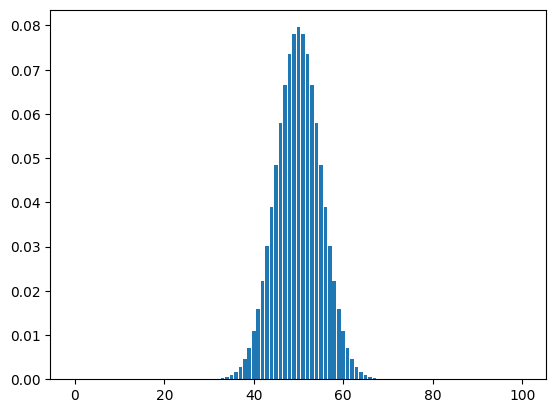

In [71]:
dist_e = My_BinomialDist(100, 0.5)
plt.bar(range(101), [dist_e.pmf(i) for i in range(101)])
plt.show()

#### 1.4.23 幾何分布の定義

$0<p<1$であると仮定し、$m=0,1,2,\dots$であるとする。

確率$p$で$1$が、確率$1-p$で$0$が生じるようなBernoulli試行を続けたとき、ちょうど$m+1$回目で初めて$1$が出る確率は、$m$回$0$が続いて$m+1$回目に$1$が出る確率

\begin{equation}
(1-p)^m×p
\end{equation}

に等しいので、

\begin{equation}
P(m)=p(1-p)^m
\end{equation}

になる。この確率質量函数で定義される可算集合{$0,1,2,\dots$}上の無限離散分布を**幾何分布**(geometric distribution)と呼び、次のように表す。

\begin{equation}
\text{Geometric}(p)
\end{equation}



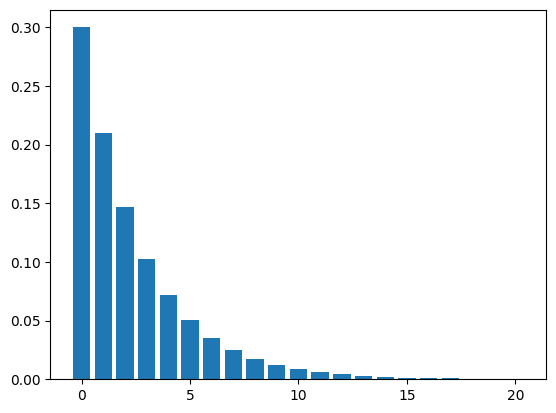

In [72]:
dist_e = My_GeometricDist(0.3)
plt.bar(range(21), [dist_e.pmf(i) for i in range(21)])
plt.show()

#### 1.4.28 負の二項分布の期待値と分散

$M$は負の二項分布に従う確率変数とし、$N=M+k$と置く。

$M$は成功確率$p$のBernoulli試行をちょうど$k$回１が出るまで繰り返すときに出た０の個数を意味する確率変数になる。

これらの期待値と分散は次のようになる

\begin{equation}
E[M]=\frac{k(1-p)}{p},E[N]=E[M]+k=\frac{k}{p},\text{var}(M)=\text{var}(N)=\frac{k(1-p)}{p^2}
\end{equation}

言ってしまえば幾何分布の$k$倍である

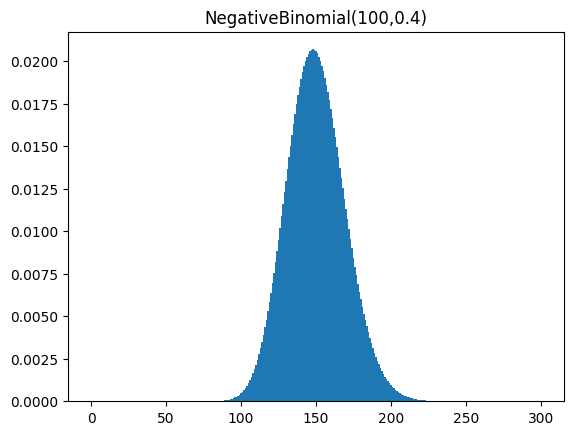

In [73]:
k=100
p=0.4
dist_h = My_NegativeBinomialDist(k, p)
plt.bar(range(301), [dist_h.pmf(i) for i in range(301)])
plt.title(f"NegativeBinomial({k},{p})")

aList = np.arange(0,300,0.01)
bList=[]

m=k*(1-p)/p
s2=k*(1-p)/(p**2)

plt.show()

#### 1.5.24 標準正規分布の累積分布函数と分位点函数

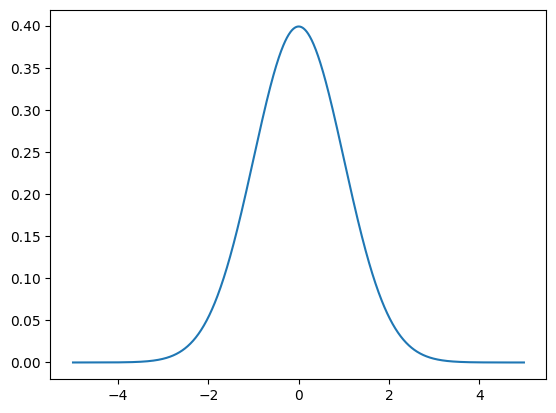

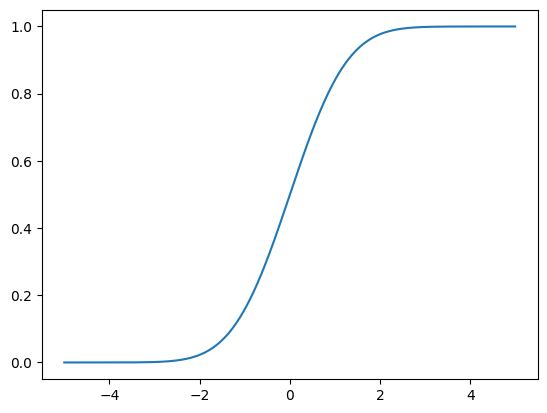

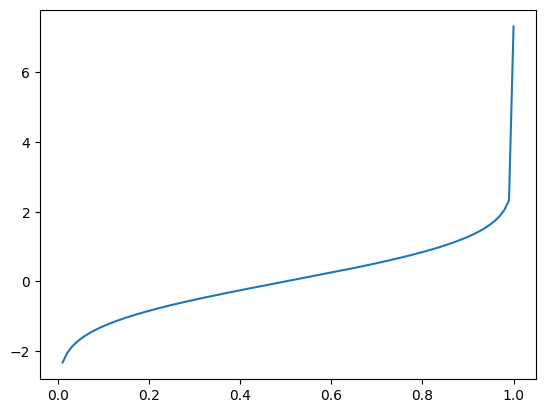

In [74]:
dist_d = My_NormalDist()

plt.plot(np.arange(-5, 5, 0.01), [dist_d.pdf(i) for i in np.arange(-5, 5, 0.01)])
plt.show()

plt.plot(np.arange(-5, 5, 0.01), [dist_d.cdf(i) for i in np.arange(-5, 5, 0.01)])
plt.show()

plt.plot(np.arange(-5, 5, 0.01), [dist_d.inv_cdf(i) for i in np.arange(-5, 5, 0.01)])
plt.show()

### 2.1 Gauss積分

### 2.2 ガンマ関数

#### 2.2.3 ガンマ分布の定義


$\alpha,\theta>0$であると仮定する

次の確率密度関数によって定義される連続分布を**形状パラメータ$\alpha$, スケールパラメータ$\theta$**の**ガンマ分布**(Gamma distribution)ｔよび、$\text{Gamma}(\alpha,\theta)$と表す。

\begin{equation}
p(x|\alpha,\theta)=\frac{1}{\theta^{\alpha}\Gamma(\alpha)}e^{-x/\theta}x^{\alpha-1}(x>0)
\end{equation}

負の二項分布の連続極限としてガンマ分布を出すことによって, ガンマ分布には「1回起こるまでにかかる時間の期待値が $\theta$ であるようなイベントが $\alpha$ 回起こるまでにかかる時間の分布」だと解釈できる. この点については後で「確率分布達の解釈」のノートで説明する.

In [75]:
gdist = My_GammaDist(30, 1)

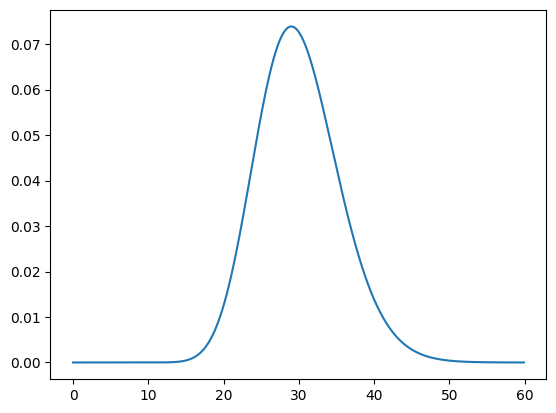

In [76]:
plt.plot(np.arange(0, 60, 0.1), [gdist.pdf(i) for i in np.arange(0, 60, 0.1)])

#### 2.2.5 指数分布の定義

\begin{equation}
\text{Exponential}(\theta)=\text{Gamma}(1,\theta)=\frac{1}{\theta}e^{-x/\theta}(x>0)
\end{equation}

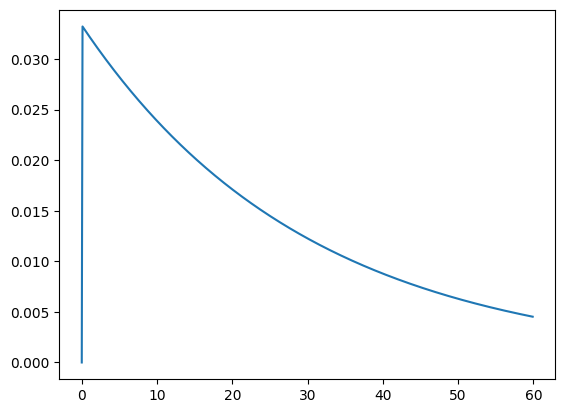

In [84]:
edist = My_ExponentialDist(30)
plt.plot(np.arange(0, 60, 0.1), [edist.pdf(i) for i in np.arange(0, 60, 0.1)])

#### 2.2.6 Laplace分布の定義

$a\in\mathbb{R},b>0$と仮定する。

\begin{equation}
p(x|a,b)=\frac{1}{2b}\text{exp}\left(-\frac{|x-a|}{b}\right)
\end{equation}

が定める$\mathbb{R}$上の連続確率分布を **Laplace分布** (ラプラス分布)と呼び,

\begin{equation}
\text{Laplace}(a.b)
\end{equation}
と書く

**ダブル指数分布** (double exponential distribution)と呼ばれることもある.

$\text{Laplace}(0, 1)$を**標準Laplace分布** と呼ぶ.

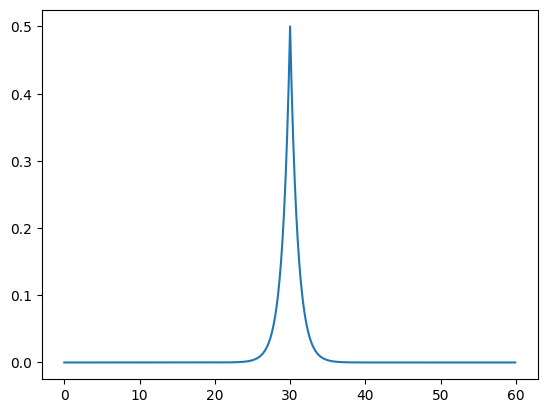

In [85]:
ldist = My_LaplaceDist(30)
plt.plot(np.arange(0, 60, 0.1), [ldist.pdf(i) for i in np.arange(0, 60, 0.1)])

#### 2.2.10 χ²分布の定義

\begin{equation}
\text{Chisq}(\nu)=\text{Gamma}(\nu/2, 2)
\end{equation}

7.814727903251179
11.344866730144373


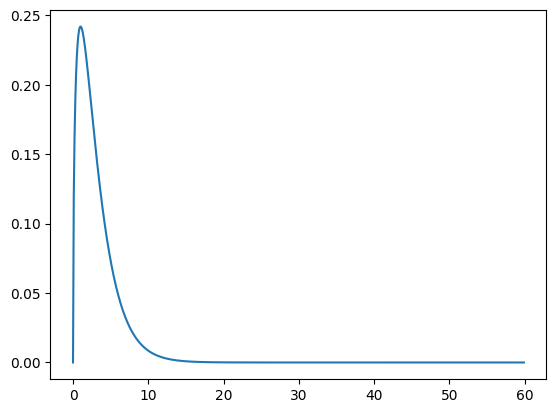

In [89]:
nu = 3
dist_c = My_ChisqDist(nu)
plt.plot(np.arange(0, 60, 0.1), [dist_c.pdf(i) for i in np.arange(0, 60, 0.1)])
print(dist_c.inv_cdf(0.95))
print(dist_c.inv_cdf(0.99))

### 2.3 ベータ関数

#### 2.3.10 $t$ 分布の定義

$\nu>0$ と仮定する.

次の確率密度函数によって定義される連続分布を **自由度** (degree of freedom) が $\nu$ の $t$ **分布** (**Student の $t$
 分布**, Student's $t$-distribution)と呼び,

\begin{equation}
\text{TDist}(\nu)
\end{equation}

と表す

\begin{equation}
p(t|\nu)=\frac{1}{\sqrt{\nu}B(1/2, \nu/2)}\left(1+\frac{t^2}{\nu}\right)^{-(\nu+1)/2}
\end{equation}

$t$ 分布は正規分布モデルによる平均に関する検定や推定で基本的な役目を果たすことになる. この点については後で別のノートで詳しく説明する.

-2.2621571628540997 2.2621571628540993
-3.2498355415921263 3.2498355415921254


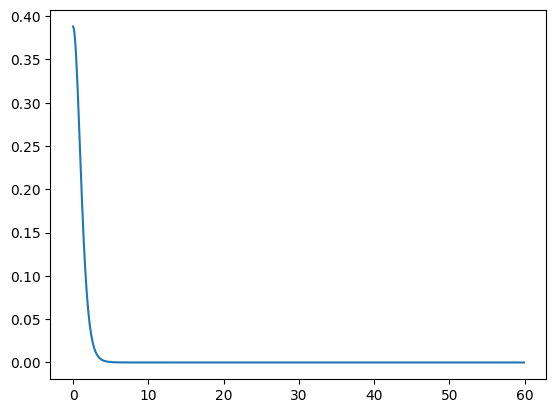

In [90]:
dist_t = My_StudentsTDist(9)
plt.plot(np.arange(0, 60, 0.1), [dist_t.pdf(i) for i in np.arange(0, 60, 0.1)])
print(dist_t.inv_cdf(0.025), dist_t.inv_cdf(1-0.025))

print(dist_t.inv_cdf(0.005), dist_t.inv_cdf(1-0.005))

#### 2.3.13 $t$ 分布と標準正規分布を同時プロット

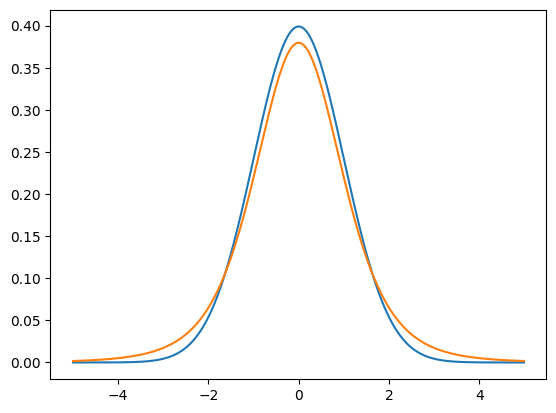

In [96]:
#@title
nu = 5 #@param {type:"number"}

dist_n=My_NormalDist()
dist_t=My_StudentsTDist(nu)

plt.plot(np.arange(-5,5,0.01), [dist_n.pdf(i) for i in np.arange(-5,5,0.01)])
plt.plot(np.arange(-5,5,0.01), [dist_t.pdf(i) for i in np.arange(-5,5,0.01)])
plt.show()

## 後編

#### 比率の検定

In [108]:
# case1
n = 20
k = 5
hypo = 0.5

alpha = 0.01

In [109]:
# case2
n = 100
k = 30
hypo = 0.3998

alpha = 0.05

In [110]:
# case3
n = 694844 + 705585
k = 694844
hypo = 0.5

alpha = 0.001

In [111]:
# case4
n = 675829 + 692996
k = 675829
hypo = 0.5

alpha = 0.001

In [114]:
# case5
n = 130
k = 65
hypo = 0.6

alpha = 0.01

In [124]:
# Clopper-Pearsonno のp値関数
pValue = min([1, 2*(1 - My_BetaDist(k+1, n-k).cdf(hypo)), 2*(My_BetaDist(k, n-k+1).cdf(hypo))])
print(pValue)

0.026408381333702158


[0.3849733849089736,0.6150266150910264]


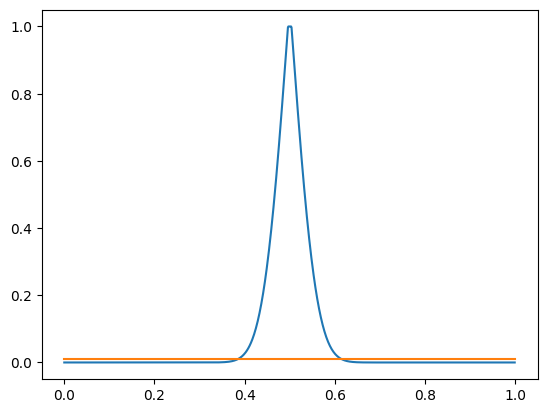

In [125]:
# Clopper-Pearson の信頼区間
p_l = My_BetaDist(k, n-k+1).inv_cdf(alpha/2)
p_u = My_BetaDist(k+1, n-k).inv_cdf(1-alpha/2)
print("[{},{}]".format(p_l, p_u))

plt.plot(np.arange(0,1,0.001), [min([1, 2*(1 - My_BetaDist(k+1, n-k).cdf(hypo)), 2*(My_BetaDist(k, n-k+1).cdf(hypo))]) for hypo in np.arange(0,1,0.001)])
plt.plot([0,1],[alpha,alpha])

0.022586888164179753
[0.38704241264781986,0.6129575873521801]


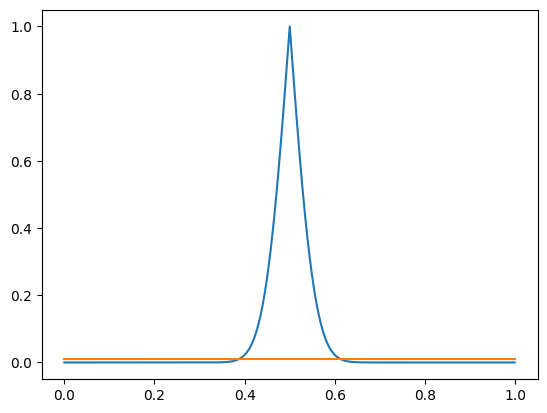

In [126]:
# Waldの信頼区間
p_hat = k/n
se_hat = math.sqrt(p_hat * (1-p_hat) / n)
pValue = 2 * (1-stcs.NormalDist().cdf(abs(k - n*hypo)/math.sqrt(n * p_hat * (1-p_hat))))
z_a = stcs.NormalDist().inv_cdf(1-alpha/2)
p_l = p_hat - z_a*se_hat
p_u = p_hat + z_a*se_hat

print(pValue)
print("[{},{}]".format(p_l, p_u))

plt.plot(np.arange(0,1,0.001), [2 * (1-stcs.NormalDist().cdf(abs(k - n*hypo)/math.sqrt(n * p_hat * (1-p_hat)))) for hypo in np.arange(0,1,0.001)])
plt.plot([0,1],[alpha,alpha])

####平均の値の検定

In [127]:
x = [13.7, 12.9, 4.4, 5.2, 3.1, 2.9, 7.2, 10.3, 4.7, 4.6, 3.6]
hypo = 9.0
alpha = 0.05

In [129]:
x = [85, 111, 69, 72, 123, 126, 87, 91, 45, 67, 114]
hypo = 110
alpha = 0.05

In [130]:
x_b = stcs.mean(x)
s2 = stcs.variance(x)
n = len(x)
t = (x_b - hypo) / math.sqrt(s2/n)
print(stcs.mean(x))
print(stcs.variance(x))

pValue = 2*(1-My_StudentsTDist(n-1).cdf(abs(t)))
print(pValue)

t_a = My_StudentsTDist(n-1).inv_cdf(1-alpha/2)
p_l = x_b - t_a* math.sqrt(s2/n)
p_u = x_b + t_a* math.sqrt(s2/n)

print("[{},{}]".format(p_l, p_u))


90
675.6
0.028764884684922665
[72.53813085710303,107.46186914289697]


#### 比率の違い

In [131]:
a=14
b=5
c=5
d=9

hypo = 1
alpha = 0.05

In [132]:
a=49
b=965
c=26
d=854

hypo = 1
alpha = 0.05

In [133]:
a=100
b=579
c=111
d=568

hypo = 1
alpha = 0.05

In [134]:
a=100
b=579
c=111
d=568

hypo = 0.5
alpha = 0.05

In [135]:
a=23
b=225
c=43
d=213

hypo = 0.9
alpha = 0.05

In [137]:
# Waldのオッズ比に関する信頼区間
print(a,b,c,d,hypo,alpha, "Wald_OR")

or_ = a*d / (b*c)
l_or_ = math.log(or_)
se_ = math.sqrt(1/a + 1/b + 1/c + 1/d)
pValue = 2 * (1 - My_NormalDist().cdf(abs(l_or_ - math.log(hypo)) / se_))
z = My_NormalDist().inv_cdf(1 -alpha/2)
confint_l_or = [l_or_ - z * se_, l_or_ + z * se_]
confint_or = [math.exp(- z * se_)*or_, math.exp(z * se_)*or_,]

print("pValue_Wald_OR={}\nconfint_Wald_logOR={}\nconfint_Wald_OR={}".format(pValue, confint_l_or, confint_or))


23 225 43 213 0.9 0.05 Wald_OR
pValue_Wald_OR=0.03679405316397055
confint_Wald_logOR=[np.float64(-1.2203885370431529), np.float64(-0.14063973547566222)]
confint_Wald_OR=[0.2951154813491478, 0.8688022539540509]


In [138]:
# Waldのリスク比に関する信頼区間
print(a,b,c,d,hypo,alpha, "Wald_RR")

rr_ = a*(c+d)/((a+b)*c)
se_ = math.sqrt(1/a - 1/(a+b) + 1/c -1/(c+d))
pValue = 2*(1 - stcs.NormalDist().cdf(abs( (math.log(rr_)-math.log(hypo)) / se_ )))
z = stcs.NormalDist().inv_cdf(1 -alpha/2)
confint_rr = [math.exp(- z * se_)*rr_, math.exp(z * se_)*rr_,]

print("pValue_Wald_RR={}\nconfint_Wald_RR={}".format(pValue, confint_rr))

23 225 43 213 0.9 0.05 Wald_RR
pValue_Wald_RR=0.043903105222160566
confint_Wald_RR=[0.343281217025051, 0.8880660928465628]


In [139]:
# Pearson の カイ二乗検定
print(a,b,c,d,hypo,alpha, "PearsonChisq")
def GetPValuePearsonChisq(a,b,c,d, hypo):
  c_a = 1- hypo
  c_b = a+d + hypo*(b+c)
  c_c = a*d - hypo * b*c
  _delta = 2 * c_c / (c_b + math.sqrt(c_b**2 - 4 * c_a * c_c))
  _a = a-_delta
  _b = b+_delta
  _c = c+_delta
  _d = d-_delta
  chi2 = _delta**2 *(1/_a + 1/_b + 1/_c + 1/_d)

  _pValue = 1- My_ChisqDist(1).cdf(chi2)
  return _pValue

pValue = GetPValuePearsonChisq(a,b,c,d,hypo)
print("pValue_Pearson_Chisq={}".format(pValue))


23 225 43 213 0.9 0.05 PearsonChisq
pValue_Pearson_Chisq=0.03506700760008341


In [140]:

_i = 0
_d = 0.1
_count = 0
while True:
  if GetPValuePearsonChisq(a,b,c,d, _i+_d) > alpha:
    if _d < 10**-8:
      p1=_i+_d
      break
    _d /= 10
    _count += 1
  else:
    _i += _d

_i += _d * 10
_d = 0.1
_count = 0
while True:
  if GetPValuePearsonChisq(a,b,c,d, _i+_d) < alpha:
    if _d < 10**-8:
      p2= _i+_d
      break
    _d /= 10
    _count += 1
  else:
    _i += _d


confint_or =[p1,p2]


print("confint_Pearson_OR={}".format(confint_or))

confint_Pearson_OR=[0.29651706099999986, 0.8650292459999999]


#### 平均の差

In [ ]:
x = [19.2, 22.7, 7.8, 138.5, 70.5, 44.3, 84.0, 35.6, 72.4, 23.9,
11.7, 26.6, 73.8, 118.3, 54.2, 57.6, 40.5, 117.4, 102.3, 67.6]
y = [44.3, 66.9, 62.9, 78.4, 71.2, 32.5, 111.4, 38.2, 68.2, 50.7,
74.5, 46.2, 65.7, 58.7, 42.5, 57.4, 63.0, 67.9, 72.1, 117.7,
124.1, 48.9, 91.8, 80.8, 60.2, 76.8, 76.3, 59.9, 70.7, 46.4]
hypo = -30

alpha = 0.05

In [ ]:
x = [162.0, 221.5, 259.3, 306.8, 184.6, 181.9, 154.8, 147.6, 240.8, 243.5,
209.3, 270.0, 170.4, 183.0, 236.7, 173.4, 212.6, 237.3, 269.4, 211.8]
m=20
y = [103.7, 200.0, 278.2, 122.6, 206.1, 185.6, 318.8, 169.7, 293.4, 152.1,
273.2, 260.4, 202.1, 113.4, 112.3, 180.3, 169.9, 143.3, 187.6, 60.2,
222.1, 284.8, 141.5, 82.8, 109.0, 179.9, 222.2, 221.7, 197.6, 118.3]
n=30

hypo = 65

alpha = 0.05

In [ ]:
# Welchのt検定
x_b = stcs.mean(x)
s2_x = stcs.variance(x)
m = len(x)
y_b = stcs.mean(y)
s2_y = stcs.variance(y)
n = len(y)

t = (x_b-y_b - hypo) / math.sqrt(s2_x/m + s2_y/n)
df = (s2_x/m + s2_y/n)**2 / ((s2_x/m)**2 /(m-1) + (s2_y/n)**2 / (n-1))
print("t分布の自由度は{}".format(df))

pValue = 2*(1-My_StudentsTDist(df).cdf(abs(t)))

print("pValue:{}".format(pValue))

t_a = My_StudentsTDist(df).inv_cdf(1-alpha/2)

confint = [x_b-y_b - t_a * math.sqrt(s2_x/m + s2_y/n), x_b-y_b + t_a * math.sqrt(s2_x/m + s2_y/n)]
print("confint:{}".format(confint))

t分布の自由度は47.9987215816756
pValue:0.03038167289163285
confint:[np.float64(-1.398981277945456), np.float64(61.54898127794549)]
